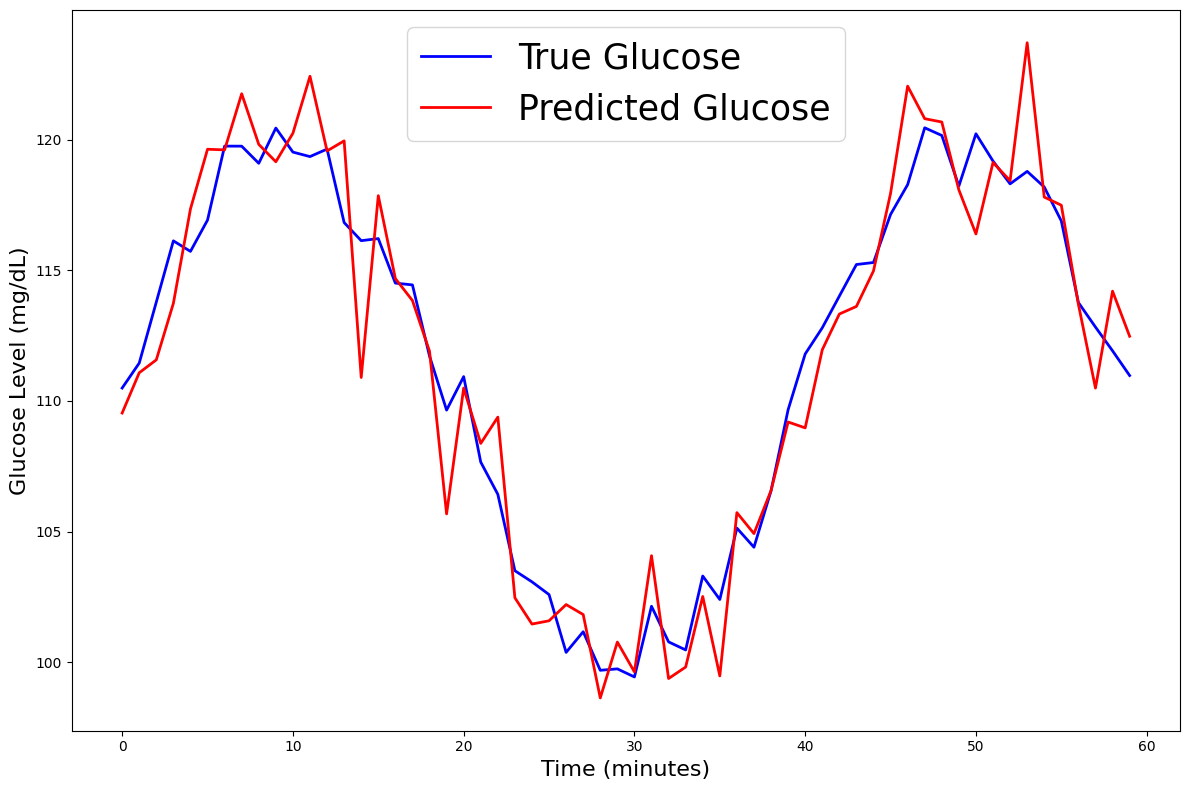

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Time axis: 60 minutes
time = np.arange(60)

# True glucose values: base + slight variation
true_glucose = 110 + np.sin(np.linspace(0, 3 * np.pi, 60)) * 10 + np.random.normal(0, 1, 60)

# Predicted glucose values: close to true values with small error
predicted_glucose = true_glucose + np.random.normal(0, 2, 60)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(time, true_glucose, label='True Glucose', color='blue', linewidth=2)
plt.plot(time, predicted_glucose, label='Predicted Glucose', color='red', linewidth=2)

# Enlarged and centered title and labels
plt.xlabel('Time (minutes)', fontsize=16)
plt.ylabel('Glucose Level (mg/dL)', fontsize=16)

# Larger legend
plt.legend(fontsize=25, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=1)

# Grid and layout
plt.tight_layout()

# Show plot
plt.show()

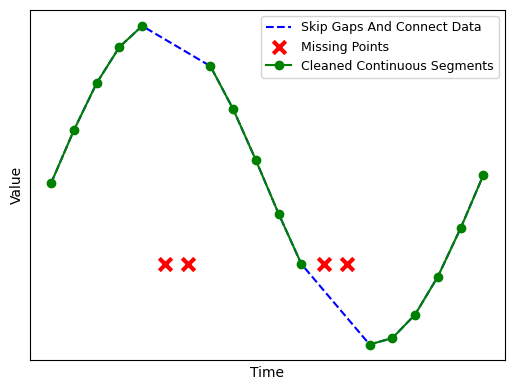

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 构造示例血糖数据（包含缺失）
time = np.arange(0, 20)
glucose = np.sin(time/3) + 5
glucose[[5, 6, 12, 13]] = np.nan  # 模拟缺失点

# 使用 pandas 进行线性插值来“连接”断点
s = pd.Series(glucose)
interpolated_glucose = s.interpolate(method='linear')

# --- 创建一张图，叠加所有元素 ---
fig, ax = plt.subplots(figsize=(5.25, 4))

# 设置背景透明
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


# 1. 绘制插值后的连接线（蓝色虚线）
ax.plot(time, interpolated_glucose, "--", color="blue", label="Skip Gaps And Connect Data")

# 2. 标记原始的缺失点
missing_idx = np.where(np.isnan(glucose))[0]
# ax.scatter(time[missing_idx], interpolated_glucose[missing_idx],  marker="x", c="red", s=80, linewidths=3, label="Missing Points")
# 自定义一个y轴位置来显示所有的叉叉
y_for_markers = 4.5 # 您可以把这个值改成任何您希望的高度
ax.scatter(time[missing_idx], [y_for_markers]*len(missing_idx),  marker="x", c="red", s=80, linewidths=3, label="Missing Points")
# 3. 绘制清理后的实际数据段（绿色实线）
# 找到连续段的起始和结束点
mask = ~np.isnan(glucose)
starts = np.where(np.diff(np.r_[0, mask, 0]) == 1)[0]
ends = np.where(np.diff(np.r_[0, mask, 0]) == -1)[0]

# 循环绘制每个连续段
for i, (start, end) in enumerate(zip(starts, ends)):
    label = "Cleaned Continuous Segments" if i == 0 else ""
    ax.plot(time[start:end], glucose[start:end], "-o", color="green", label=label)

# --- 设置图表 ---
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(fontsize=9)
ax.set_yticklabels([])  # 不显示y轴数值
ax.set_xticklabels([])  # 不显示x轴数值
plt.yticks([]) 
plt.xticks([]) 
plt.tight_layout()
plt.show()

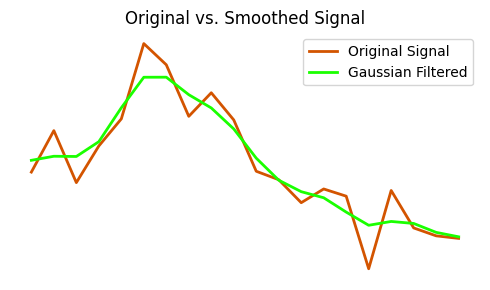

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
np.random.seed(2025)
# 生成模拟数据
x = np.linspace(0, 5, 20)
original_signal = np.sin(x) + np.random.normal(0, 0.5, x.shape)
smoothed_signal = gaussian_filter1d(original_signal, sigma=1)

# 颜色适配紫色底（推荐亮色系）
line_color =  "#D35400"  # 金色
smooth_color = "#1AFF00"  # 青色

# --- 将两条曲线绘制在同一张图中 ---
fig, ax = plt.subplots(figsize=(5, 3)) 

# 绘制原始信号
ax.plot(x, original_signal, color=line_color, linewidth=2, label='Original Signal')
# 绘制平滑后的信号
ax.plot(x, smoothed_signal, color=smooth_color, linewidth=2, label='Gaussian Filtered')

# 设置图表属性
ax.set_title('Original vs. Smoothed Signal', color='black')
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.legend()

# 设置背景透明
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
# plt.savefig('combined_signal.png', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()